# vanilla rnn

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:

print("available:", torch.cuda.is_available())
print("version", torch.version.cuda)
if torch.cuda.is_available():
    print("count", torch.cuda.device_count())
    print("name", torch.cuda.get_device_name(0))


available: False
version 12.8


In [4]:
data = pd.read_csv("/media/karthik/C482D9F182D9E7C6/git/data.txt", header=None, names=["name", "language"])

In [5]:
label_encoder = LabelEncoder()
data['lang_idx'] = label_encoder.fit_transform(data['language'])
num_classes = len(label_encoder.classes_)


In [6]:
all_chars = sorted(list(set(''.join(data['name'].str.lower()))))
char2idx = {ch:i+1 for i,ch in enumerate(all_chars)}  # 0 for padding
idx2char = {i:ch for ch,i in char2idx.items()}

In [8]:
max_len = max(data['name'].str.len())
print(max_len)

19


In [9]:
def encode_name(name):
    name = name.lower()
    encoded = [char2idx[ch] for ch in name]
    # pad with 0s
    while len(encoded) < max_len:
        encoded.append(0)
    return encoded

data['name_encoded'] = data['name'].apply(encode_name)

In [13]:
X = list(data['name_encoded'])
y = list(data['lang_idx'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
class NameDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = NameDataset(X_train, y_train)
test_dataset = NameDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Data ready!")
print(f"Number of classes: {num_classes}")
print(f"Max name length: {max_len}")

Data ready!
Number of classes: 19
Max name length: 19


In [19]:
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_classes):
        super(VanillaRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size+1, embed_size, padding_idx=0)  # +1 for padding
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)  # (batch, seq_len, embed_size)
        out, _ = self.rnn(x)   # out: (batch, seq_len, hidden_size)
        out = out[:, -1, :]    # take last time step
        out = self.fc(out)
        return out

# Hyperparameters
vocab_size = len(char2idx)
embed_size = 32
hidden_size = 64

model = VanillaRNN(vocab_size, embed_size, hidden_size, num_classes).to(device)
print(model)

VanillaRNN(
  (embedding): Embedding(29, 32, padding_idx=0)
  (rnn): RNN(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=19, bias=True)
)


In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


In [21]:
num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for names, labels in train_loader:
        names, labels = names.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(names)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/30], Loss: 1.8926
Epoch [2/30], Loss: 1.8578
Epoch [3/30], Loss: 1.8566
Epoch [4/30], Loss: 1.8571
Epoch [5/30], Loss: 1.8586
Epoch [6/30], Loss: 1.8550
Epoch [7/30], Loss: 1.8566
Epoch [8/30], Loss: 1.8551
Epoch [9/30], Loss: 1.8564
Epoch [10/30], Loss: 1.8917
Epoch [11/30], Loss: 1.9932
Epoch [12/30], Loss: 1.9434
Epoch [13/30], Loss: 1.8814
Epoch [14/30], Loss: 1.8544
Epoch [15/30], Loss: 1.8521
Epoch [16/30], Loss: 1.8515
Epoch [17/30], Loss: 1.8525
Epoch [18/30], Loss: 1.8510
Epoch [19/30], Loss: 1.8529
Epoch [20/30], Loss: 1.8514
Epoch [21/30], Loss: 1.8513
Epoch [22/30], Loss: 1.8503
Epoch [23/30], Loss: 1.8506
Epoch [24/30], Loss: 1.8510
Epoch [25/30], Loss: 1.8490
Epoch [26/30], Loss: 1.8506
Epoch [27/30], Loss: 1.8514
Epoch [28/30], Loss: 1.8486
Epoch [29/30], Loss: 1.8475
Epoch [30/30], Loss: 1.8473


Vanilla RNN Accuracy: 47.16%


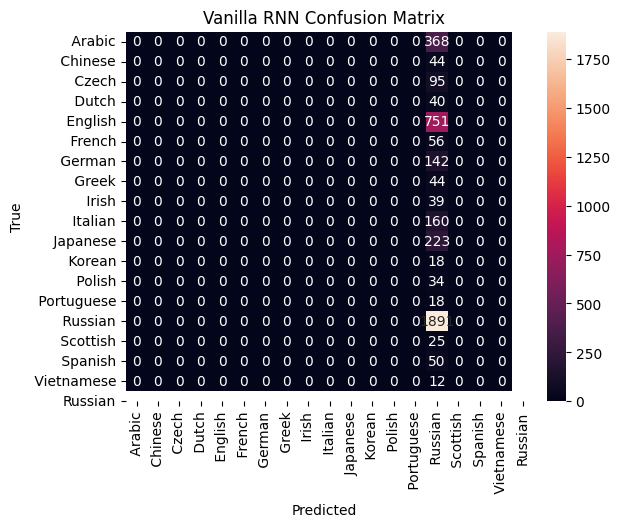

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for names, labels in test_loader:
        names, labels = names.to(device), labels.to(device)
        outputs = model(names)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"Vanilla RNN Accuracy: {acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Vanilla RNN Confusion Matrix")
plt.show()


# lstm

In [24]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_classes):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size+1, embed_size, padding_idx=0)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        out, (hn, cn) = self.lstm(x)  # hn: last hidden state
        out = hn[-1]  # take last layer's hidden state
        out = self.fc(out)
        return out

# Create LSTM model
lstm_model = LSTMModel(vocab_size, embed_size, hidden_size, num_classes).to(device)
print(lstm_model)


LSTMModel(
  (embedding): Embedding(29, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=19, bias=True)
)


In [25]:
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
num_epochs = 30

for epoch in range(num_epochs):
    lstm_model.train()
    total_loss = 0
    for names, labels in train_loader:
        names, labels = names.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = lstm_model(names)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")


Epoch [1/30], Loss: 1.7217
Epoch [2/30], Loss: 1.3519
Epoch [3/30], Loss: 1.1149
Epoch [4/30], Loss: 0.9516
Epoch [5/30], Loss: 0.8484
Epoch [6/30], Loss: 0.7768
Epoch [7/30], Loss: 0.7293
Epoch [8/30], Loss: 0.6932
Epoch [9/30], Loss: 0.6589
Epoch [10/30], Loss: 0.6209
Epoch [11/30], Loss: 0.6055
Epoch [12/30], Loss: 0.5866
Epoch [13/30], Loss: 0.5576
Epoch [14/30], Loss: 0.5376
Epoch [15/30], Loss: 0.5196
Epoch [16/30], Loss: 0.5014
Epoch [17/30], Loss: 0.4821
Epoch [18/30], Loss: 0.4773
Epoch [19/30], Loss: 0.4583
Epoch [20/30], Loss: 0.4482
Epoch [21/30], Loss: 0.4318
Epoch [22/30], Loss: 0.4158
Epoch [23/30], Loss: 0.4053
Epoch [24/30], Loss: 0.3915
Epoch [25/30], Loss: 0.3830
Epoch [26/30], Loss: 0.3749
Epoch [27/30], Loss: 0.3684
Epoch [28/30], Loss: 0.3503
Epoch [29/30], Loss: 0.3433
Epoch [30/30], Loss: 0.3295


LSTM Accuracy: 81.60%


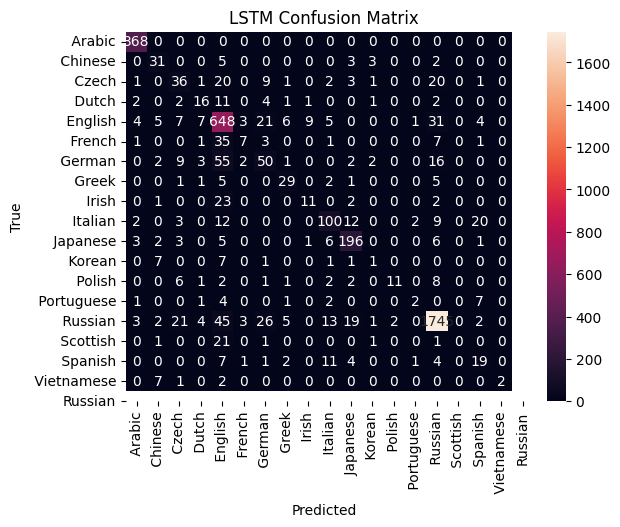

In [26]:
lstm_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for names, labels in test_loader:
        names, labels = names.to(device), labels.to(device)
        outputs = lstm_model(names)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"LSTM Accuracy: {acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("LSTM Confusion Matrix")
plt.show()


# gru

In [27]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_classes):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size+1, embed_size, padding_idx=0)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        out, hn = self.gru(x)  # hn: last hidden state
        out = hn[-1]  # take last layer's hidden state
        out = self.fc(out)
        return out

# Create GRU model
gru_model = GRUModel(vocab_size, embed_size, hidden_size, num_classes).to(device)
print(gru_model)


GRUModel(
  (embedding): Embedding(29, 32, padding_idx=0)
  (gru): GRU(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=19, bias=True)
)


In [29]:
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
num_epochs = 30

for epoch in range(num_epochs):
    gru_model.train()
    total_loss = 0
    for names, labels in train_loader:
        names, labels = names.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = gru_model(names)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")


Epoch [1/30], Loss: 1.0650
Epoch [2/30], Loss: 0.9475
Epoch [3/30], Loss: 0.8608
Epoch [4/30], Loss: 0.7837
Epoch [5/30], Loss: 0.7326
Epoch [6/30], Loss: 0.6887
Epoch [7/30], Loss: 0.6537
Epoch [8/30], Loss: 0.6229
Epoch [9/30], Loss: 0.5989
Epoch [10/30], Loss: 0.5739
Epoch [11/30], Loss: 0.5495
Epoch [12/30], Loss: 0.5309
Epoch [13/30], Loss: 0.5124
Epoch [14/30], Loss: 0.4993
Epoch [15/30], Loss: 0.4769
Epoch [16/30], Loss: 0.4635
Epoch [17/30], Loss: 0.4450
Epoch [18/30], Loss: 0.4320
Epoch [19/30], Loss: 0.4154
Epoch [20/30], Loss: 0.4039
Epoch [21/30], Loss: 0.3924
Epoch [22/30], Loss: 0.3759
Epoch [23/30], Loss: 0.3631
Epoch [24/30], Loss: 0.3592
Epoch [25/30], Loss: 0.3389
Epoch [26/30], Loss: 0.3320
Epoch [27/30], Loss: 0.3175
Epoch [28/30], Loss: 0.3069
Epoch [29/30], Loss: 0.3040
Epoch [30/30], Loss: 0.2930


GRU Accuracy: 81.05%


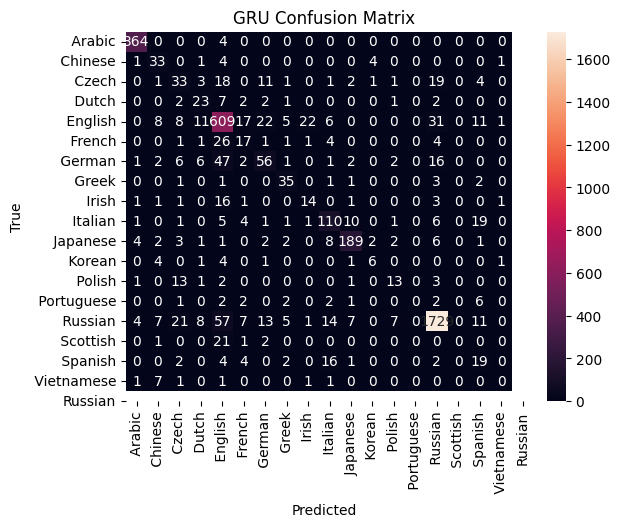

In [30]:
gru_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for names, labels in test_loader:
        names, labels = names.to(device), labels.to(device)
        outputs = gru_model(names)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"GRU Accuracy: {acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("GRU Confusion Matrix")
plt.show()
